# Machine Learning Final Project
# Predicting Student Academic Performance Using Machine Learning
# Alyssa Peterson

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import urllib.request
from io import BytesIO

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Load the UCI Student Performance dataset


In [20]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00320/student.zip"

response = urllib.request.urlopen(url)
zip_file = zipfile.ZipFile(BytesIO(response.read()))

# Using the Portuguese language course dataset
df = pd.read_csv(zip_file.open("student-por.csv"), sep=";")

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


# Basic dataset information


In [21]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (649, 33)

Column names:
Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

Missing values:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


# Define student academic performance as Pass/Fail
# G3 is the final grade on a 0-20 scale.
# Pass = final grade 10 or higher
# Fail = final grade below 10

In [22]:
df["performance"] = df["G3"].apply(lambda grade: "Pass" if grade >= 10 else "Fail")

print(df["performance"].value_counts())
print(df["performance"].value_counts(normalize=True))

performance
Pass    549
Fail    100
Name: count, dtype: int64
performance
Pass    0.845917
Fail    0.154083
Name: proportion, dtype: float64


# Visualize class balance

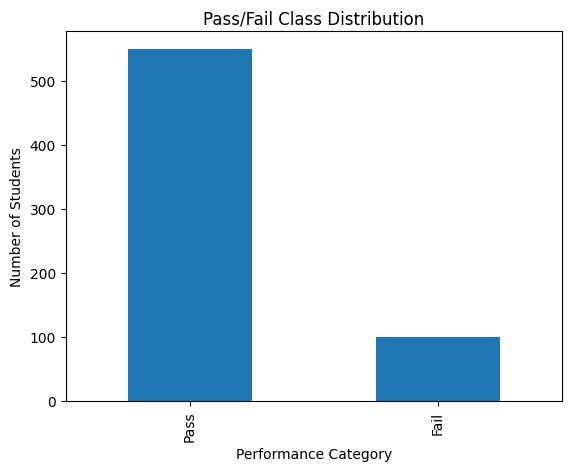

In [23]:
df["performance"].value_counts().plot(kind="bar")
plt.title("Pass/Fail Class Distribution")
plt.xlabel("Performance Category")
plt.ylabel("Number of Students")
plt.show()

# Separate features and target
# Drop G3 because it is the final grade we are predicting.
# G1 and G2 are kept because they represent previous academic performance.

In [24]:
X = df.drop(columns=["G3", "performance"])
y = df["performance"]

# Identify categorical and numerical columns
categorical_features = X.select_dtypes(include=["object"]).columns
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns

print("Categorical features:", list(categorical_features))
print("Numerical features:", list(numerical_features))

Categorical features: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
Numerical features: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']


# Train, validation, and test split
# First split into training+validation and test
# Then split training+validation into training and validation

In [25]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,
    random_state=42,
    stratify=y_train_val
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (389, 32)
Validation set: (130, 32)
Test set: (130, 32)


# Preprocessing
# Categorical features are one-hot encoded.
# Numerical features are scaled.

In [26]:
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numerical", StandardScaler(), numerical_features)
    ]
)

# Create machine learning models

In [27]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=6,
        random_state=42,
        class_weight="balanced"
    )
}

# Train and evaluate models on the validation set

In [28]:
results = []

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)

    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred, pos_label="Fail")
    recall = recall_score(y_val, y_pred, pos_label="Fail")
    f1 = f1_score(y_val, y_pred, pos_label="Fail")

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })

results_df = pd.DataFrame(results)
results_df


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.907692,0.653846,0.85,0.739130
1,Decision Tree,0.900000,0.666667,0.70,0.682927
2,Random Forest,0.930769,0.823529,0.70,0.756757


# Select the best model based on F1-score

In [29]:
best_model_name = results_df.sort_values(by="F1-score", ascending=False).iloc[0]["Model"]
best_model = models[best_model_name]

print("Best model based on F1-score:", best_model_name)

Best model based on F1-score: Random Forest


# Train the best model on the combined training and validation data
# Then evaluate it on the final test set

In [30]:
final_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", best_model)
])

final_pipeline.fit(X_train_val, y_train_val)
y_test_pred = final_pipeline.predict(X_test)

print("Final Test Results")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred, pos_label="Fail"))
print("Recall:", recall_score(y_test, y_test_pred, pos_label="Fail"))
print("F1-score:", f1_score(y_test, y_test_pred, pos_label="Fail"))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

Final Test Results
Accuracy: 0.8538461538461538
Precision: 0.52
Recall: 0.65
F1-score: 0.5777777777777777

Classification Report:
              precision    recall  f1-score   support

        Fail       0.52      0.65      0.58        20
        Pass       0.93      0.89      0.91       110

    accuracy                           0.85       130
   macro avg       0.73      0.77      0.74       130
weighted avg       0.87      0.85      0.86       130



# Confusion matrix for the final model


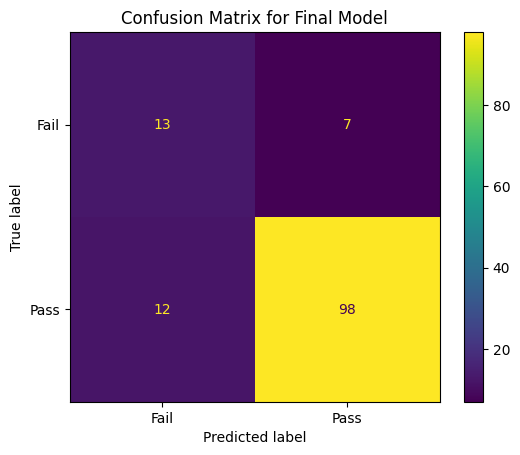

In [31]:
cm = confusion_matrix(y_test, y_test_pred, labels=["Fail", "Pass"])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fail", "Pass"])
disp.plot()
plt.title("Confusion Matrix for Final Model")
plt.show()

# Cross-validation for generalization check

In [32]:
cv_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", best_model)
])

cv_scores = cross_val_score(
    cv_pipeline,
    X_train_val,
    y_train_val,
    cv=5,
    scoring="f1_macro"
)

print("Cross-validation F1 scores:", cv_scores)
print("Average cross-validation F1 score:", cv_scores.mean())

Cross-validation F1 scores: [0.82417582 0.83792208 0.83204134 0.92613636 0.85201149]
Average cross-validation F1 score: 0.8544574207312781


### Results

Three supervised machine learning models were trained and compared: Logistic Regression, Decision Tree, and Random Forest. The models were evaluated on the validation set using accuracy, precision, recall, and F1-score. Since the dataset had more passing students than failing students, F1-score was used as the main metric because it balances precision and recall.

The Random Forest model had the highest validation F1-score, so it was selected as the final model. On the validation set, Random Forest reached an accuracy of 0.9308, precision of 0.8235, recall of 0.7000, and F1-score of 0.7568 for the Fail class.

After selecting the Random Forest model, it was trained again using the combined training and validation data. It was then evaluated on the final test set. The final test accuracy was 0.8538. For the Fail class, the model had a precision of 0.52, recall of 0.65, and F1-score of 0.5778.

### Model Interpretation

The final model correctly predicted 13 failing students and 98 passing students. It incorrectly predicted 7 failing students as passing and 12 passing students as failing. This shows that the model was much stronger at predicting students who passed than students who failed.

This matters because the Fail class is the more important class for this project. If the goal is to identify students who may need academic support, then missing a failing student could mean missing an opportunity to help. The recall score of 0.65 for the Fail class means the model correctly identified 65% of the students who actually failed. While this is not perfect, it is still useful as an early warning signal when combined with human judgment.

### Cross-Validation and Generalization

Cross-validation was used to check whether the Random Forest model generalized well across different splits of the data. The five cross-validation F1 macro scores were approximately 0.8242, 0.8379, 0.8320, 0.9261, and 0.8520. The average cross-validation F1 macro score was 0.8545.

These results suggest that the model performed consistently across different portions of the dataset. This helps show that the model was not only performing well on one specific split of the data.

### Bias and Fairness

One concern with this dataset is that student performance may be affected by factors outside of a student’s control, such as family background, school support, access to study time, and demographic variables. Because of this, the model should be interpreted carefully. A prediction of “Fail” should not be treated as a permanent label or punishment. Instead, it should be used as a signal that a student may benefit from extra academic support.

There was also class imbalance in the dataset. There were 549 passing students and 100 failing students, meaning the model saw many more examples of students who passed. To address this, I used stratified train, validation, and test splits so the class proportions were preserved. I also used class weights in the models and evaluated performance using precision, recall, and F1-score instead of relying only on accuracy.

### Overfitting Prevention

Several strategies were used to reduce overfitting. First, the data was split into training, validation, and test sets. The validation set was used to compare models before evaluating the final model on the test set. Second, cross-validation was used to check how consistently the model performed across different splits of the data. Third, model complexity was limited by using maximum depth settings for the Decision Tree and Random Forest models. Logistic Regression also used regularization, which helps prevent the model from fitting too closely to the training data.

### Reflection

This project helped me understand how supervised machine learning can be applied to a real-world education problem. One of the most important decisions was defining student academic performance clearly. I chose a pass/fail classification, where students with a final grade of 10 or higher were classified as Pass and students below 10 were classified as Fail.

One challenge was the class imbalance in the dataset. Since most students passed, accuracy alone could have made the model look better than it really was. Because of this, I focused on precision, recall, F1-score, and the confusion matrix. This helped me better understand how well the model identified students who may be at risk of failing.

I also learned that machine learning models in education need to be used carefully. A model like this should not replace teachers, counselors, or human judgment. Instead, it could be used as an early warning tool to help educators notice students who may need extra support. Overall, this project gave me practice with preprocessing, model comparison, evaluation metrics, overfitting prevention, and ethical thinking in machine learning.

### Conclusion

The Random Forest model was the best-performing model based on validation F1-score. The final test results showed that the model performed well overall, with an accuracy of 0.8538. However, the model was better at predicting students who passed than students who failed.

The most important takeaway is that this type of model could be useful as a support tool, but it should not be used as the only basis for academic decisions. Since the model missed some students who actually failed, educators would still need to combine model predictions with classroom knowledge, student context, and professional judgment.